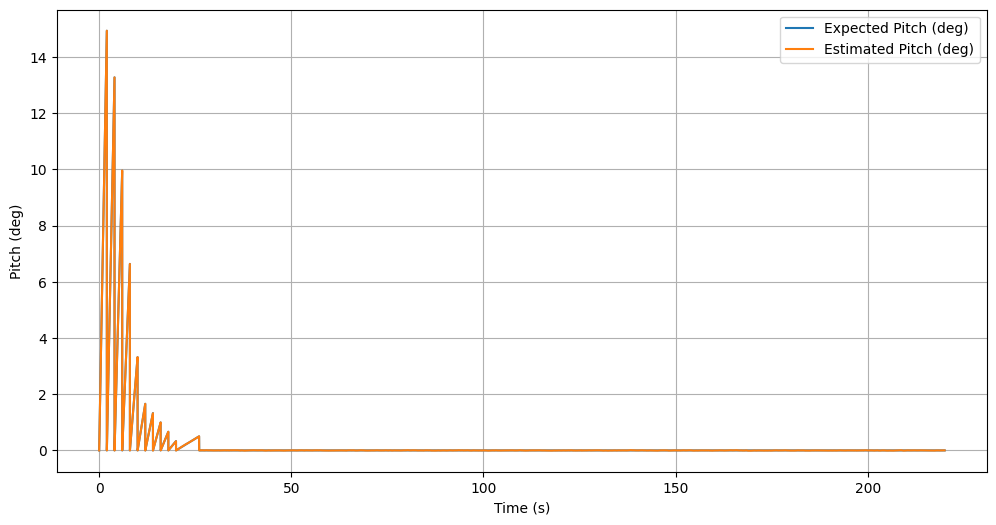

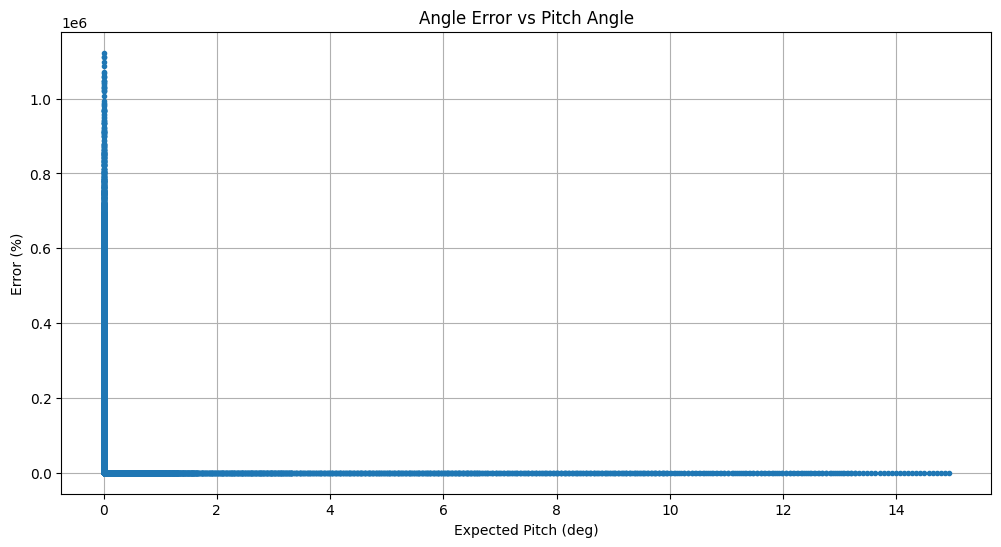

In [5]:
import numpy as np
import matplotlib.pyplot as plt
 
# Simulation parameters
fs = 104  # Hz
dt = 1/fs
angles = [45,40,30,20,10,5,4,3,2,1,0.5]
T = len(angles)*20  # total time in seconds
t = np.arange(0, T, dt)
 
# Sensor noise (from datasheet)
gyro_noise_density = 0.005  # deg/s/√Hz
accel_noise_density = 60e-6  # g/√Hz
g = 9.80665
 
# Convert accel noise density to angle noise density (small angle approx)
Sa_deg = accel_noise_density * (180/np.pi)  # deg/√Hz
Sg_deg = gyro_noise_density  # deg/s/√Hz
 
# %%
# Define a ground truth sequence: rest -> pitch up to 45° -> rest -> yaw rotate 90° -> rest
angles_pitch = np.zeros_like(t)
angles_yaw = np.zeros_like(t)

for idx, angle in enumerate(angles):
    # Create pitch motion (altitude change)
    pitch_start, pitch_end = 2*idx, 2*idx+6  # seconds
    pitch_angle = angle  # deg
    mask = (t >= pitch_start) & (t <= pitch_end)
    angles_pitch[mask] = np.linspace(0, pitch_angle, mask.sum())
    
    # Create yaw motion (azimuth change)
    yaw_start, yaw_end = 10*idx, 10*idx+14
    yaw_angle = angle  # deg
    mask = (t >= yaw_start) & (t <= yaw_end)
    angles_yaw[mask] = np.linspace(0, yaw_angle, mask.sum())
 
# Combine ground truth
angles_truth = np.vstack([angles_pitch, angles_yaw]).T  # [N, 2]
 
# %%
# Generate synthetic accelerometer and gyro readings from ground truth
 
def angles_to_accel(pitch_deg):
    # Only simulate pitch: accel measures tilt from gravity
    pitch_rad = np.deg2rad(pitch_deg)
    ax = np.sin(pitch_rad) * g
    ay = 0
    az = np.cos(pitch_rad) * g
    return np.array([ax, ay, az])
 
def angles_to_gyro(prev_angle, curr_angle):
    # Gyro measures angular velocity (deg/s)
    return (curr_angle - prev_angle) / dt
 
# Simulate
accel_data = []
gyro_data = []
for i in range(len(t)):
    pitch, yaw = angles_truth[i]
    # accel only sensitive to pitch (simplified)
    accel = angles_to_accel(pitch)
    # add accel noise
    accel += np.random.normal(0, accel_noise_density * g * np.sqrt(fs/2), 3)
    accel_data.append(accel)
 
    if i > 0:
        gyro_pitch = angles_to_gyro(angles_truth[i-1,0], pitch)
        gyro_yaw = angles_to_gyro(angles_truth[i-1,1], yaw)
    else:
        gyro_pitch, gyro_yaw = 0, 0
    # add gyro noise
    gyro_pitch += np.random.normal(0, Sg_deg*np.sqrt(fs/2))
    gyro_yaw += np.random.normal(0, Sg_deg*np.sqrt(fs/2))
    gyro_data.append([gyro_pitch, gyro_yaw])
 
accel_data = np.array(accel_data)
gyro_data = np.array(gyro_data)
 
# %%
# Complementary filter (for pitch only, since yaw has no accel reference)
fc = 0.23  # Hz cutoff
alpha = 1 - (dt * 2 * np.pi * fc)  # simple discrete approx
 
pitch_est = np.zeros_like(t)
for i in range(1, len(t)):
    gyro_rate = gyro_data[i,0]  # deg/s
    accel_angle = np.rad2deg(np.arctan2(accel_data[i,0], accel_data[i,2]))
    pitch_est[i] = alpha*(pitch_est[i-1] + gyro_rate*dt) + (1-alpha)*accel_angle
 
# %%
# Metrics: error %, DPS
expected_pitch = angles_truth[:,0]
error = np.abs(pitch_est - expected_pitch)
error_percent = (error / np.maximum(expected_pitch, 1e-6)) * 100  # avoid div0
dps = np.gradient(expected_pitch, dt)
 
# %%
# Plot results
plt.figure(figsize=(12,6))
plt.plot(t, expected_pitch, label="Expected Pitch (deg)")
plt.plot(t, pitch_est, label="Estimated Pitch (deg)")
plt.xlabel("Time (s)")
plt.ylabel("Pitch (deg)")
plt.legend()
plt.grid()
plt.show()
 
plt.figure(figsize=(12,6))
plt.plot(expected_pitch, error_percent, ".")
plt.xlabel("Expected Pitch (deg)")
plt.ylabel("Error (%)")
plt.title("Angle Error vs Pitch Angle")
plt.grid()
plt.show()

In [6]:
def segmentation_gaps(df):
    # Detect time gaps for segmentation
    gap_threshold = 5.0  # seconds
    timestamps = df["timestamp"].values
    gaps = np.where(np.abs(np.diff(timestamps)) > gap_threshold)[0]

    # Create segment boundaries
    segment_bounds = []
    start = 0
    for gap_idx in gaps:
        segment_bounds.append((start, gap_idx + 1))
        start = gap_idx + 1
    segment_bounds.append((start, len(df)))

    print(f"Found {len(segment_bounds)} segments:")
    for i, (start, end) in enumerate(segment_bounds):
        duration = df.iloc[end-1]['timestamp'] - df.iloc[start]['timestamp']
        print(f"  Segment {i}: samples {start}-{end-1}, duration {duration:.1f}s")

    # Map to test configuration if available
    segments = []
    for i, (start, end) in enumerate(segment_bounds):
        segment_data = df.iloc[start:end].copy()
        segments.append({
            'test_id': i,
            'data': segment_data.reset_index(),
            'start_idx': start,
            'end_idx': end
        })
    return segments

In [7]:
import pandas as pd
from motion_estimator import MotionEstimator
 
df = pd.read_csv("raw_data_output_altitude.csv")
required_cols = ["timestamp", "accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z"]
missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

# Convert to numeric
for col in required_cols[1:]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
# Drop rows with NaN values in required columns
df = df.dropna(subset=required_cols)
# Convert from EDN (East-Down-North) to NED (North-East-Down) coordinate system
# This ensures Az (Z-axis) is aligned with gravity vector
# EDN -> NED transformation:
# X_EDN -> Y_NED (East -> East)  
# Y_EDN -> -Z_NED (Down -> -Down)
# Z_EDN -> X_NED (North -> North)

# Accelerometer conversion
accel_x_ned = df["accel_z"].copy()  # North (Z_EDN -> X_NED)
accel_y_ned = df["accel_x"].copy()  # East (X_EDN -> Y_NED)  
accel_z_ned = -df["accel_y"].copy() # Down (Y_EDN -> -Z_NED)

df["accel_x"] = accel_x_ned
df["accel_y"] = accel_y_ned
df["accel_z"] = accel_z_ned

# Gyroscope conversion (same transformation)
gyro_x_ned = df["gyro_z"].copy()  # North
gyro_y_ned = df["gyro_x"].copy()  # East
gyro_z_ned = -df["gyro_y"].copy() # Down

df["gyro_x"] = gyro_x_ned
df["gyro_y"] = gyro_y_ned
df["gyro_z"] = gyro_z_ned

segments = segmentation_gaps(df)

# # Process first 5 seconds of data (104 Hz * 5 sec = 520 samples) to get reference
# for segment in segments:
#     test_id, data, start_idx, end_idx = segment.values()
#     for i in range(start_idx, end_idx):
#             _ref_pitch_deg = []
            

#         update(
#             [data["accel_x"][i], data["accel_y"][i], data["accel_z"][i]],
#             [data["gyro_x"][i], data["gyro_y"][i], data["gyro_z"][i]],
#             data["timestamp"][i]
#         )
#         _ref_pitch_deg.append(_prev_pitch_deg)
#         _ref_roll_deg.append(_prev_roll_deg)
#         _ref_yaw_deg.append(_prev_yaw_deg)
#     printState()

Found 12 segments:
  Segment 0: samples 0-7068, duration 64.0s
  Segment 1: samples 7069-14048, duration 63.1s
  Segment 2: samples 14049-21043, duration 63.2s
  Segment 3: samples 21044-24877, duration 34.6s
  Segment 4: samples 24878-28643, duration 34.1s
  Segment 5: samples 28644-32543, duration 35.1s
  Segment 6: samples 32544-36583, duration 36.4s
  Segment 7: samples 36584-40743, duration 37.5s
  Segment 8: samples 40744-44419, duration 33.1s
  Segment 9: samples 44420-47983, duration 32.2s
  Segment 10: samples 47984-51803, duration 34.4s
  Segment 11: samples 51804-55614, duration 34.4s


In [ ]:
estimator = MotionEstimator()
 
# Process first segment
seg = segments[0]["data"]
outputs = []
for segment in segments:
    test_id, data, start_idx, end_idx = segment.values()
    segment_result = {}
    for i, row in seg.iterrows():
        accel_raw = [row["accel_x"], row["accel_y"], row["accel_z"]]  # mg
        gyro_raw = [row["gyro_x"], row["gyro_y"], row["gyro_z"]]      # dps
        ts = row["timestamp"]
        output = estimator.update(accel_raw, gyro_raw, ts)
        segment_result = {'test_id': test_id}
        segment_result.update(output)
        outputs.append(segment_result)

# Based on the test_id, we know what angle was changed at what time. (e.g., test 0 has no angle change)
out_df = pd.DataFrame(outputs)
print(out_df.head())

   test_id    yaw_deg  pitch_deg   roll_deg  timestamp
0        0   9.523667  -4.542216  12.315268      0.743
1        0  17.929202  -9.050495  21.814222      0.743
2        0  25.476013 -13.665760  29.760735      0.743
3        0  32.363322 -18.186747  36.502021      0.743
4        0  38.744135 -22.615864  42.151782      0.743
